<a href="https://colab.research.google.com/github/JosephBless/Deep-Learning-Colab/blob/main/Chap_5%EF%BC%9A%E5%9B%9E%E6%B8%AC%E6%A1%86%E6%9E%B6%E4%BB%8B%E7%B4%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

在本節中，我們將深入了解量化投資中至關重要的部分——回測。透過回測，我們可以在歷史數據上測試交易策略的有效性，評估其風險和收益特性。我們將介紹兩個流行的Python回測框架：Backtrader和Zipline，並學習如何使用它們來進行策略回測。

---

### **一、為什麼需要回測**

回測（Backtesting）是指在歷史數據上測試交易策略，以評估其在過去的表現。透過回測，我們可以：

- **評估策略的可行性**：確認策略是否具有盈利能力。
- **理解策略的風險特性**：包括波動性、最大回撤等。
- **優化策略參數**：調整策略中的參數以達到最佳性能。
- **避免過擬合**：透過在不同的歷史時期進行測試，確保策略的穩健性。

---

### **二、Python回測框架**

#### **1. Backtrader**

- **簡介**：Backtrader是一個功能強大且靈活的Python回測框架，支持多種資產類別、指標和執行模式。
- **特點**：
  - 支持多資料源和多資產回測。
  - 內置大量的技術指標和分析工具。
  - 支持實時數據和紙上交易（Paper Trading）。

#### **2. Zipline**

- **簡介**：Zipline是Quantopian開發的Python回測引擎，專為構建和評估量化交易策略而設計。
- **特點**：
  - 支持日級別和分鐘級別的數據回測。
  - 提供豐富的金融數據處理功能。
  - 與Pandas和NumPy緊密集成。

---

### **三、使用Backtrader進行回測**

#### **1. 安裝Backtrader**

在Colab中安裝Backtrader：

In [ ]:
!pip install backtrader


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 5.9 MB/s eta 0:00:00


In [ ]:
!pip install yfinance==0.2.44


#### **2. 建立策略類**

在Backtrader中，您需要繼承`bt.Strategy`類，並實現策略的邏輯。

In [ ]:
import backtrader as bt

class SmaCrossStrategy(bt.Strategy):
    params = dict(
        sma_short_period=10,
        sma_long_period=50,
    )

    def __init__(self):
        self.sma_short = bt.ind.SMA(period=self.p.sma_short_period)
        self.sma_long = bt.ind.SMA(period=self.p.sma_long_period)
        self.crossover = bt.ind.CrossOver(self.sma_short, self.sma_long)

    def next(self):
        if not self.position:
            if self.crossover > 0:
                self.buy()
        elif self.crossover < 0:
            self.sell()

#### **3. 獲取數據**

使用`yfinance`獲取數據，並轉換為Backtrader的數據格式。

In [ ]:
import yfinance as yf
import pandas as pd

data = yf.download('AAPL', start='2020-01-01', end='2024-09-01')
data_bt = bt.feeds.PandasData(dataname=data)

[*********************100%***********************]  1 of 1 completed


#### **4. 設置回測環境並執行**


In [ ]:
cerebro = bt.Cerebro()
cerebro.addstrategy(SmaCrossStrategy)
cerebro.adddata(data_bt)
cerebro.broker.setcash(100000.0)
cerebro.run()

#### **5. 結果分析**

**打印最終資產淨值：**

In [ ]:
print(f'最終資產淨值: {cerebro.broker.getvalue():.2f}')


最終資產淨值: 100110.18


**繪製回測結果：**


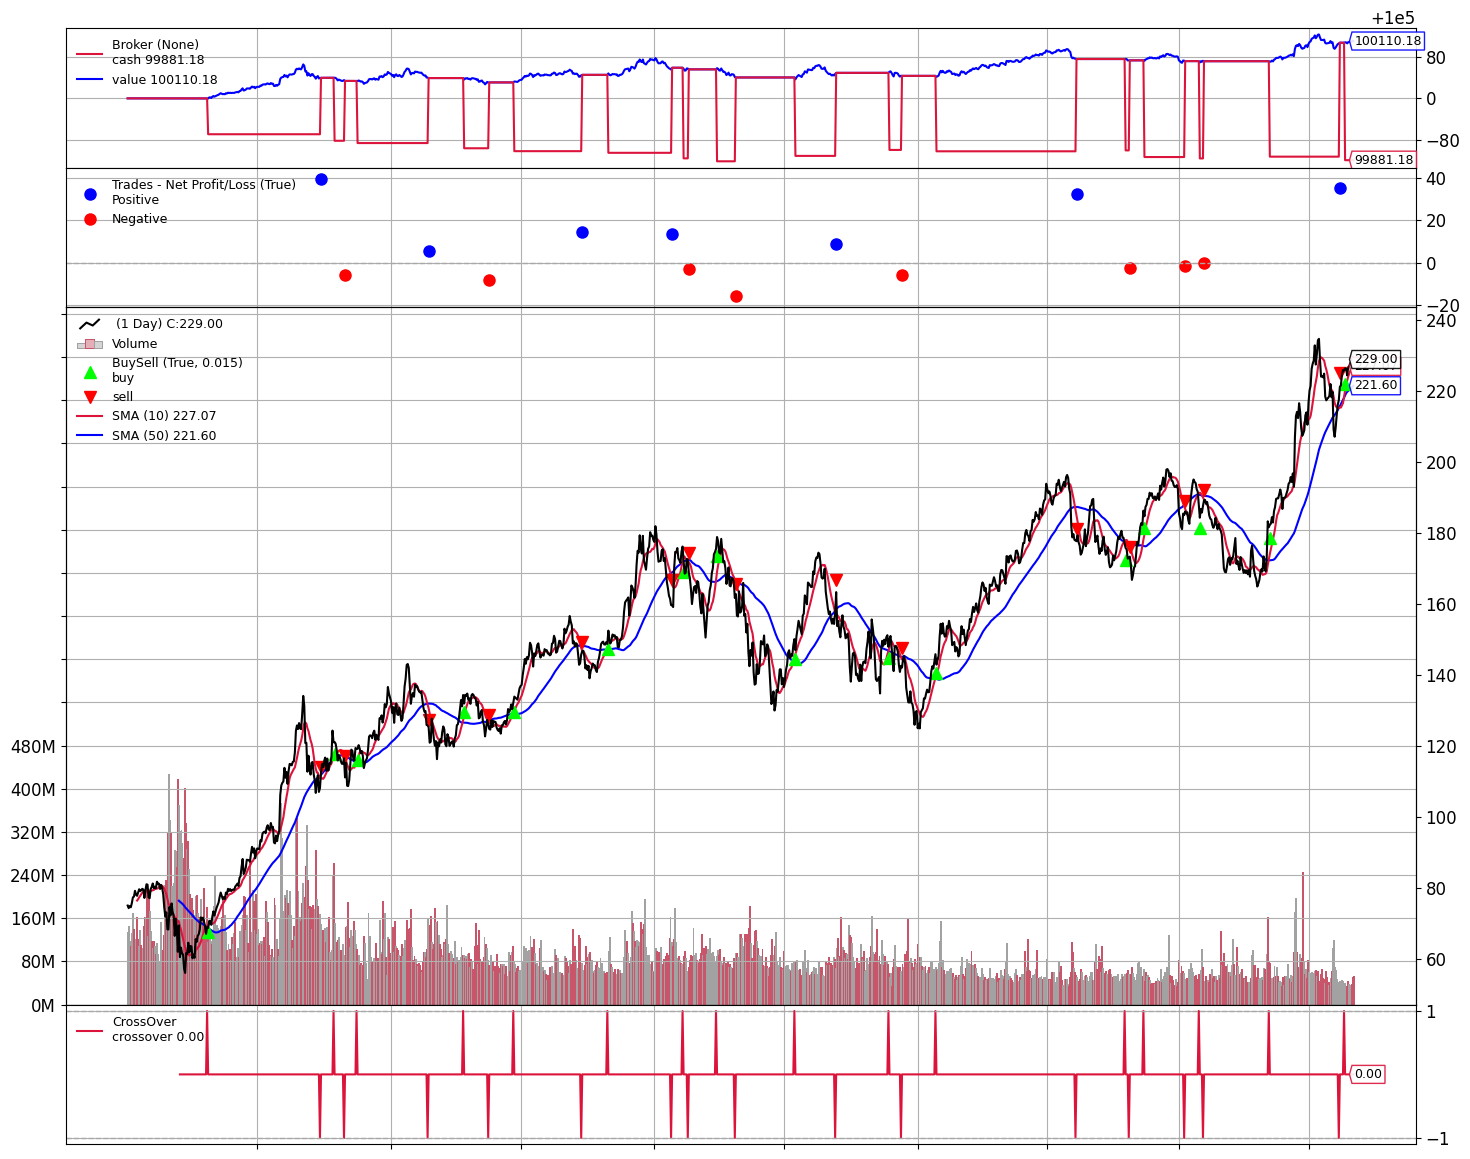

In [ ]:
#https://www.roelpeters.be/how-to-use-backtrader-plots-in-python-notebooks/
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = [15, 12]
plt.rcParams.update({'font.size': 12})
img = cerebro.plot(iplot = False)
img[0][0].savefig('backtrader.png')

### **四、使用Zipline進行回測**

**注意**：Zipline在Colab中可能不易安裝，且支持有限。如果您希望使用Zipline，建議在本地環境或支持的環境中進行。

---

### **五、回測結果解讀**

#### **1. 重要指標**

- **累計收益率**：策略在回測期間的總收益率。
- **年化收益率**：將總收益率換算為年化數值。
- **最大回撤**：回測期間資產淨值最大的下降幅度。
- **夏普比率**：衡量策略的風險調整後收益。

#### **2. 分析方法**

- **與基準比較**：將策略的表現與市場指數進行比較。
- **查看交易明細**：分析每筆交易的盈虧情況。
- **時間序列圖表**：觀察資產淨值隨時間的變化。

---

### **六、回測中的注意事項**

#### **1. 資料質量**

- 確保使用高質量的歷史數據，避免數據錯誤影響回測結果。

#### **2. 滑點和交易成本**

- 在回測中考慮交易成本，如手續費和滑點，以模擬真實交易環境。


In [ ]:
cerebro.broker.setcommission(commission=0.001)  # 設置手續費為0.1%
cerebro.broker.set_slippage_perc(0.001)         # 設置滑點為0.1%

#### **3. 過擬合風險**

- 避免過度調整策略參數，以免在未來市場中表現不佳。

#### **4. 交易邏輯的合理性**

- 確保策略符合市場邏輯，不依賴偶然的數據模式。

---

### **七、進一步探索**

#### **1. 添加性能分析**

使用Backtrader的分析器（Analyzer）獲取更多的性能指標。

In [ ]:
cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe')
cerebro.addanalyzer(bt.analyzers.DrawDown, _name='drawdown')

完整程式:

[*********************100%***********************]  1 of 1 completed



最終資產淨值: 100032.89
夏普比率: -39.17
最大回撤: 0.03%
總交易次數: 4


<IPython.core.display.Javascript object>

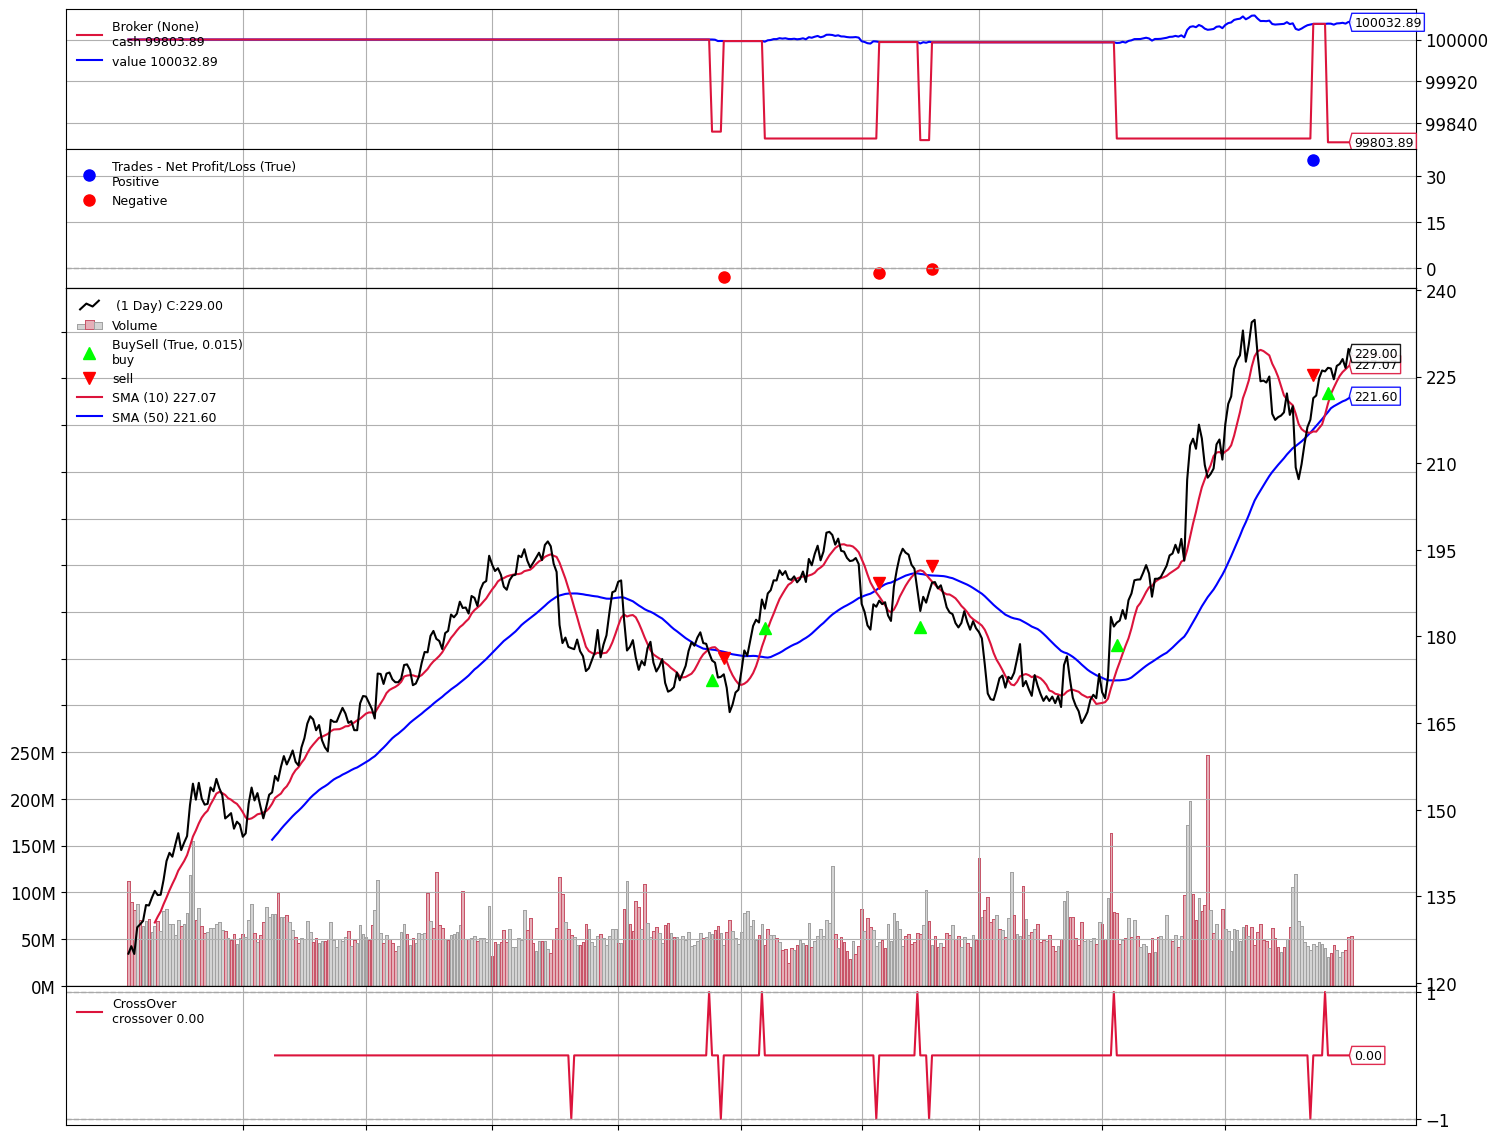

[[<Figure size 1500x1200 with 5 Axes>]]

In [ ]:
import backtrader as bt
import yfinance as yf

# 定義策略
class SmaCrossStrategy(bt.Strategy):
    params = dict(
        sma_short_period=10,
        sma_long_period=50,
    )

    def __init__(self):
        self.sma_short = bt.ind.SMA(period=self.p.sma_short_period)
        self.sma_long = bt.ind.SMA(period=self.p.sma_long_period)
        self.crossover = bt.ind.CrossOver(self.sma_short, self.sma_long)

    def next(self):
        if not self.position:
            if self.crossover > 0:
                self.buy()
        elif self.crossover < 0:
            self.close()

# 獲取數據
data = yf.download('AAPL', start='2023-01-01', end='2024-09-01')
data_bt = bt.feeds.PandasData(dataname=data)

# 設置回測環境
cerebro = bt.Cerebro()
cerebro.addstrategy(SmaCrossStrategy)
cerebro.adddata(data_bt)
cerebro.broker.setcash(100000.0)
cerebro.broker.setcommission(commission=0.001)
cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe',
                    timeframe=bt.TimeFrame.Days, annualize=True, riskfreerate=0.01)
cerebro.addanalyzer(bt.analyzers.DrawDown, _name='drawdown')
cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name='trade_analyzer')

# 執行回測
results = cerebro.run()
sharpe = results[0].analyzers.sharpe.get_analysis()
drawdown = results[0].analyzers.drawdown.get_analysis()
trade_analyzer = results[0].analyzers.trade_analyzer.get_analysis()

# 打印結果
print("\n")
print(f"最終資產淨值: {cerebro.broker.getvalue():.2f}")
if sharpe.get('sharperatio') is not None:
    print(f"夏普比率: {sharpe['sharperatio']:.2f}")
else:
    print("夏普比率無法計算，請檢查策略和數據。")

print(f"最大回撤: {drawdown.max.drawdown:.2f}%")
print(f"總交易次數: {trade_analyzer.total.closed}")

# 繪製圖表
cerebro.plot()

# 如果在 Colab 之上:
#https://www.roelpeters.be/how-to-use-backtrader-plots-in-python-notebooks/
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = [15, 12]
plt.rcParams.update({'font.size': 12})
cerebro.plot(iplot = False)

#### **2. 多策略比較**

- 在同一回測環境中測試多個策略，比較它們的表現。

#### **3. 實時數據與紙上交易**

- Backtrader支持連接實時數據源，可進行紙上交易測試。

---

### **八、總結**

在本節中，我們：

- **了解了回測的重要性**，以及它在策略開發中的角色。
- **學習了如何使用Backtrader進行回測**，包括數據導入、策略實現和結果分析。
- **討論了回測中的關鍵注意事項**，如交易成本、過擬合和資料質量。

*透過回測，我們能夠在進入實際交易之前評估策略的有效性。接下來，我們將探索如何引入AI技術，提升交易策略的智能化水平。*

---

**作業：**

1. **嘗試不同的策略參數**：修改均線的週期（如20日、50日），觀察對回測結果的影響。
2. **添加性能指標**：使用Backtrader的分析器，計算策略的年化收益率、夏普比率和最大回撤。
3. **實現其他策略**：嘗試實現基於其他技術指標（如RSI、MACD）的策略，並進行回測。

*透過實踐，您將更深入地理解回測框架的使用方法，為開發高效的交易策略奠定基礎。*

---

[*********************100%***********************]  1 of 1 completed


最終資產淨值: 100075.35
夏普比率: -68.25
最大回撤: 0.04%
總交易次數: 17


<IPython.core.display.Javascript object>

[[<Figure size 1500x1200 with 5 Axes>]]